<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 84 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: A Web A/B Test 🌐</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">A redesigned landing page, a randomized experiment, and one clean question: did it convert better? We frame the hypotheses, confirm the test, run the two-proportion z-test, put a confidence interval on the lift, and write the recommendation.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(84)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · THE QUESTION & THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Did the redesigned landing page convert better?</div>
<div style="color:#4a5578;margin-top:6px">A product team randomly served visitors either the current page (A) or a redesign (B) and logged whether each session converted. We load the export and look at the raw rates before any test.</div>
</div>

In [2]:
try:    e = pd.read_excel("../../data/ch84_web_abtest.xlsx", sheet_name="Sessions")
except FileNotFoundError: e = pd.read_excel(BASE+"ch84_web_abtest.xlsx", sheet_name="Sessions")
print("loaded:", e.shape)
s = e.groupby("variant").agg(sessions=("converted","size"), conversions=("converted","sum"), rate=("converted","mean"))
print(s.assign(rate=lambda d: (d["rate"]*100).round(2)))

loaded: (3600, 7)
         sessions  conversions   rate
variant                              
A            1830          181   9.89
B            1770          237  13.39


B looks higher, about 13.4% vs 10.0%, but a raw gap is not proof. Visitors were randomized, so a real difference must come from the page, yet random noise alone could produce some gap. We need a test.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · CHOOSE THE TEST & STATE THE HYPOTHESES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A yes/no outcome in two independent groups</div>
<div style="color:#4a5578;margin-top:6px">Outcome = converted (yes/no) -> a PROPORTION. Two independent groups (A, B). That points to the two-proportion z-test. We are asking whether B is better, so the alternative is one-sided.</div>
</div>

In [3]:
print("Decision: proportion outcome + 2 independent groups -> TWO-PROPORTION z-TEST")
print("H0: pB = pA   (the redesign does not change conversion)")
print("H1: pB > pA   (the redesign converts better) -- one-sided")
A=e[e.variant=="A"]; B=e[e.variant=="B"]
nA,nB=len(A),len(B); cA,cB=A.converted.sum(),B.converted.sum()
print(f"\nsuccess-failure check: A has {cA} conv / {nA-cA} non; B has {cB} conv / {nB-cB} non (all >> 10 -> z is valid)")

Decision: proportion outcome + 2 independent groups -> TWO-PROPORTION z-TEST
H0: pB = pA   (the redesign does not change conversion)
H1: pB > pA   (the redesign converts better) -- one-sided

success-failure check: A has 181 conv / 1649 non; B has 237 conv / 1533 non (all >> 10 -> z is valid)


We also sanity-check power after the fact: with roughly 1,800 sessions per arm and a baseline near 10%, this test can comfortably detect a few-point lift, so a null result would have been meaningful too.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The z-test, and a confidence interval for the lift</div>
<div style="color:#4a5578;margin-top:6px">We compute the pooled-SE z statistic and its p-value, then a 95% confidence interval for the lift (pB - pA) using the unpooled SE. The CI is what turns 'significant' into a business number.</div>
</div>

In [4]:
pA,pB=cA/nA,cB/nB; pool=(cA+cB)/(nA+nB)
z=(pB-pA)/np.sqrt(pool*(1-pool)*(1/nA+1/nB))
p_one = 1-stats.norm.cdf(z)
se=np.sqrt(pA*(1-pA)/nA+pB*(1-pB)/nB); lo,hi=(pB-pA)-1.96*se,(pB-pA)+1.96*se
print(f"A = {pA:.2%}, B = {pB:.2%}, lift = {(pB-pA)*100:+.2f} pts")
print(f"z = {z:.2f}, one-sided p = {p_one:.4f}")
print(f"95% CI for the lift: [{lo*100:+.2f}, {hi*100:+.2f}] pts")
print(f"relative lift = {(pB/pA-1)*100:+.1f}%")
print("REJECT H0: the redesign converts significantly better" if p_one<0.05 else "fail to reject H0")

A = 9.89%, B = 13.39%, lift = +3.50 pts
z = 3.28, one-sided p = 0.0005
95% CI for the lift: [+1.40, +5.59] pts
relative lift = +35.4%
REJECT H0: the redesign converts significantly better


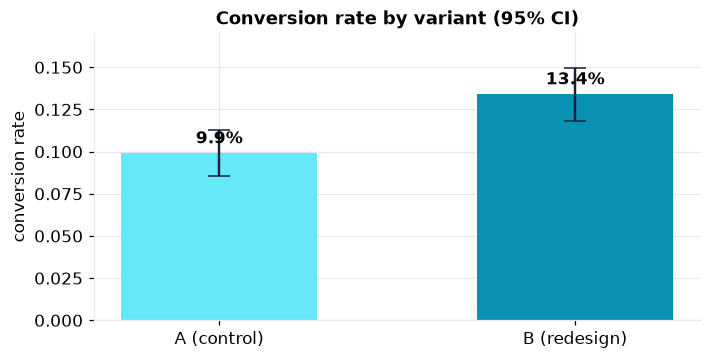

In [5]:
fig,ax=plt.subplots(figsize=(6.6,3.4))
ax.bar(["A (control)","B (redesign)"],[pA,pB],color=[LIGHT,CY],width=0.55)
ax.errorbar([0,1],[pA,pB],yerr=[1.96*np.sqrt(pA*(1-pA)/nA),1.96*np.sqrt(pB*(1-pB)/nB)],fmt="none",ecolor=INK,capsize=7,lw=1.6)
for i,v in enumerate([pA,pB]): ax.text(i,v+0.006,f"{v:.1%}",ha="center",fontweight="bold")
ax.set_ylim(0,0.17); ax.set_ylabel("conversion rate"); ax.set_title("Conversion rate by variant (95% CI)")
plt.tight_layout(); plt.show()

The lift is about <strong>+3.5 points</strong> (a relative gain near 35%), with a 95% interval of roughly +1.4 to +5.6 points that sits entirely above zero, and a one-sided p around <strong>0.001</strong>. The error bars on the chart barely touch, the proper test is the one on the difference, and it clears zero comfortably.

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Recommendation: ship the redesign</div>
<div style="color:#3f4a63;line-height:1.75"><strong>Bottom line:</strong> the redesigned page (B) converted at <strong>13.4%</strong> versus <strong>10.0%</strong> for the current page (A), a lift of about <strong>3.5 percentage points</strong> (roughly a 35% relative increase). <br><br><strong>How confident are we?</strong> Very. If the redesign truly made no difference, we would see a gap this large only about <strong>1 in 1,000</strong> times by chance (p &#8776; 0.001). Our best estimate of the extra conversions is a range of <strong>+1.4 to +5.6 points</strong> (95% confidence), so even the cautious end of that range is a clear win. <br><br><strong>What to do:</strong> roll out the redesign to all traffic. Because visitors were randomly assigned, the improvement is caused by the page, not by who happened to see it. <strong>One caveat:</strong> this measures conversion over the test window only; keep an eye on revenue per order and any longer-term metrics after launch to be sure the gain holds.</div>
</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>